In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Everything works!")

Everything works!


In [15]:
df = pd.read_csv("./data/Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [17]:
# Convert Order Date to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Check the data type
df["Order Date"].dtype

dtype('<M8[us]')

In [18]:
# Display the first and last order dates
print("First order:", df["Order Date"].min())
print("Last order:", df["Order Date"].max())

First order: 2014-01-03 00:00:00
Last order: 2017-12-30 00:00:00


In [19]:
# Create monthly sales dataset
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


In [20]:
print(monthly_sales.shape)

monthly_sales.tail()

(48, 2)


,Order Date,Sales
43,2017-08-01,63120.8880
44,2017-09-01,87866.6520
45,2017-10-01,77776.9232
46,2017-11-01,118447.8250
47,2017-12-01,83829.3188


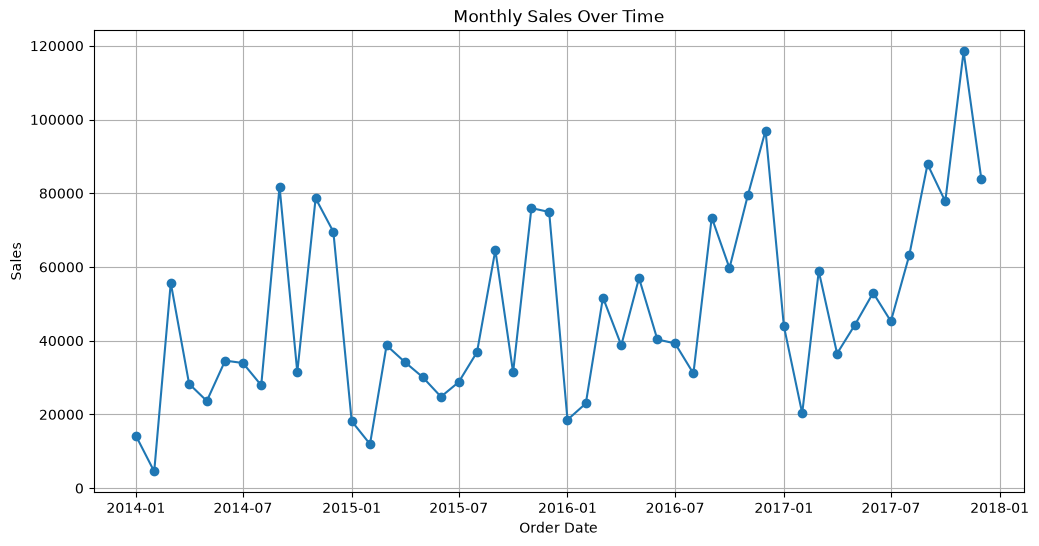

In [21]:
# Plot monthly sales over time

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [25]:
# Observations
# - Monthly sales fluctuate over time.
# - There is an overall upward trend in sales.
# - Several months show noticeable sales peaks.
# - These patterns suggest that forecasting future sales is feasible.

In [26]:
# Create time-based features

monthly_sales["Year"] = monthly_sales["Order Date"].dt.year
monthly_sales["Month"] = monthly_sales["Order Date"].dt.month

monthly_sales.head()

,Order Date,Sales,Year,Month
0,2014-01-01,14236.895,2014,1
1,2014-02-01,4519.892,2014,2
2,2014-03-01,55691.009,2014,3
3,2014-04-01,28295.345,2014,4
4,2014-05-01,23648.287,2014,5


In [27]:
# Create lag features

monthly_sales["Lag_1"] = monthly_sales["Sales"].shift(1)
monthly_sales["Lag_2"] = monthly_sales["Sales"].shift(2)
monthly_sales["Lag_3"] = monthly_sales["Sales"].shift(3)

monthly_sales.head(10)

,Order Date,Sales,Year,Month,Lag_1,Lag_2,Lag_3
0,2014-01-01,14236.8950,2014,1,NaN,NaN,NaN
1,2014-02-01,4519.8920,2014,2,14236.8950,NaN,NaN
2,2014-03-01,55691.0090,2014,3,4519.8920,14236.8950,NaN
3,2014-04-01,28295.3450,2014,4,55691.0090,4519.8920,14236.8950
4,2014-05-01,23648.2870,2014,5,28295.3450,55691.0090,4519.8920
5,2014-06-01,34595.1276,2014,6,23648.2870,28295.3450,55691.0090
6,2014-07-01,33946.3930,2014,7,34595.1276,23648.2870,28295.3450
7,2014-08-01,27909.4685,2014,8,33946.3930,34595.1276,23648.2870
8,2014-09-01,81777.3508,2014,9,27909.4685,33946.3930,34595.1276
9,2014-10-01,31453.3930,2014,10,81777.3508,27909.4685,33946.3930


In [28]:
# Create rolling average

monthly_sales["Rolling_Mean_3"] = (
    monthly_sales["Sales"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

monthly_sales.head(10)

,Order Date,Sales,Year,Month,Lag_1,Lag_2,Lag_3,Rolling_Mean_3
0,2014-01-01,14236.8950,2014,1,NaN,NaN,NaN,NaN
1,2014-02-01,4519.8920,2014,2,14236.8950,NaN,NaN,NaN
2,2014-03-01,55691.0090,2014,3,4519.8920,14236.8950,NaN,NaN
3,2014-04-01,28295.3450,2014,4,55691.0090,4519.8920,14236.8950,24815.932000
4,2014-05-01,23648.2870,2014,5,28295.3450,55691.0090,4519.8920,29502.082000
5,2014-06-01,34595.1276,2014,6,23648.2870,28295.3450,55691.0090,35878.213667
6,2014-07-01,33946.3930,2014,7,34595.1276,23648.2870,28295.3450,28846.253200
7,2014-08-01,27909.4685,2014,8,33946.3930,34595.1276,23648.2870,30729.935867
8,2014-09-01,81777.3508,2014,9,27909.4685,33946.3930,34595.1276,32150.329700
9,2014-10-01,31453.3930,2014,10,81777.3508,27909.4685,33946.3930,47877.737433


In [29]:
# Remove missing values

monthly_sales = monthly_sales.dropna()

monthly_sales.head()

,Order Date,Sales,Year,Month,Lag_1,Lag_2,Lag_3,Rolling_Mean_3
3,2014-04-01,28295.3450,2014,4,55691.0090,4519.8920,14236.895,24815.932000
4,2014-05-01,23648.2870,2014,5,28295.3450,55691.0090,4519.892,29502.082000
5,2014-06-01,34595.1276,2014,6,23648.2870,28295.3450,55691.009,35878.213667
6,2014-07-01,33946.3930,2014,7,34595.1276,23648.2870,28295.345,28846.253200
7,2014-08-01,27909.4685,2014,8,33946.3930,34595.1276,23648.287,30729.935867


In [30]:
# Check dataset information

monthly_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 3 to 47
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order Date      45 non-null     datetime64[us]
 1   Sales           45 non-null     float64       
 2   Year            45 non-null     int32         
 3   Month           45 non-null     int32         
 4   Lag_1           45 non-null     float64       
 5   Lag_2           45 non-null     float64       
 6   Lag_3           45 non-null     float64       
 7   Rolling_Mean_3  45 non-null     float64       
dtypes: datetime64[us](1), float64(5), int32(2)
memory usage: 2.6 KB


In [31]:
# Select features and target

features = ["Year", "Month", "Lag_1", "Lag_2", "Lag_3", "Rolling_Mean_3"]
target = "Sales"

X = monthly_sales[features]
y = monthly_sales[target]

In [32]:
# Split data into training and testing sets

X_train = X.iloc[:-6]
X_test = X.iloc[-6:]

y_train = y.iloc[:-6]
y_test = y.iloc[-6:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39
Testing samples: 6


In [33]:
# Train Random Forest model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [34]:
# Predict sales

predictions = model.predict(X_test)

predictions

array([40285.77623 , 44325.98857 , 58626.344963, 56121.354272,
       79908.603269, 81355.987498])

In [35]:
# Evaluate the model

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 19280.33
RMSE: 23070.12


In [36]:
# Create comparison dataframe

results = pd.DataFrame({
    "Date": monthly_sales["Order Date"].iloc[-6:].values,
    "Actual Sales": y_test.values,
    "Predicted Sales": predictions
})

results

,Date,Actual Sales,Predicted Sales
0,2017-07-01,45264.4160,40285.776230
1,2017-08-01,63120.8880,44325.988570
2,2017-09-01,87866.6520,58626.344963
3,2017-10-01,77776.9232,56121.354272
4,2017-11-01,118447.8250,79908.603269
5,2017-12-01,83829.3188,81355.987498


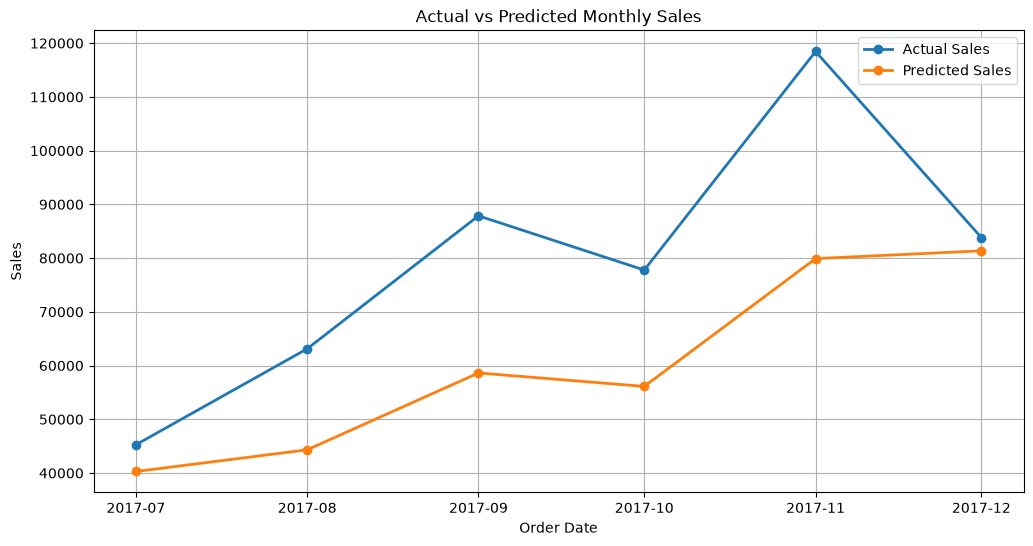

In [37]:
# Plot actual vs predicted sales

plt.figure(figsize=(12,6))

plt.plot(
    results["Date"],
    results["Actual Sales"],
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    results["Date"],
    results["Predicted Sales"],
    marker="o",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
# Conclusion
#
# The Random Forest model was trained to predict monthly sales
# based on historical sales data.
#
# The model achieved:
# - MAE: 19,280.33
# - RMSE: 23,070.12
#
# Although the model does not perfectly predict monthly sales,
# it captures the general sales trend and can support business
# planning and inventory management.
#
# Future improvements may include:
# - adding more historical data,
# - creating additional time-based features,
# - testing other forecasting models such as XGBoost, Prophet, or LSTM.

In [40]:
# Create baseline predictions using the previous month's sales

baseline_predictions = X_test["Lag_1"]

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_predictions)
)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Random Forest MAE: {mae:.2f}")
print(f"Random Forest RMSE: {rmse:.2f}")


Baseline MAE: 22616.45
Baseline RMSE: 25642.18
Random Forest MAE: 19280.33
Random Forest RMSE: 23070.12


In [41]:
plt.tight_layout()
plt.savefig(
    "./images/actual_vs_predicted_sales.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [43]:
import joblib

In [44]:
# Save the trained model

joblib.dump(model, "./models/random_forest_sales_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [45]:
# Conclusion
#
# A Random Forest regression model was developed to predict monthly
# sales using historical sales and time-based features.
#
# The model was evaluated on the final six months of the dataset
# using MAE and RMSE. Its performance was also compared with a
# baseline model that predicts the next month using the previous
# month's sales.
#
# The results demonstrate the importance of comparing machine
# learning models with simple forecasting methods.
#
# Possible future improvements include:
# - collecting more historical data,
# - adding seasonal features,
# - using time-series cross-validation,
# - tuning the model hyperparameters,
# - testing models such as XGBoost, SARIMA, or Prophet.

In [46]:
import joblib

In [47]:
# Save the trained model

joblib.dump(model, "./models/random_forest_sales_model.pkl")

print("Model saved successfully!")

Model saved successfully!


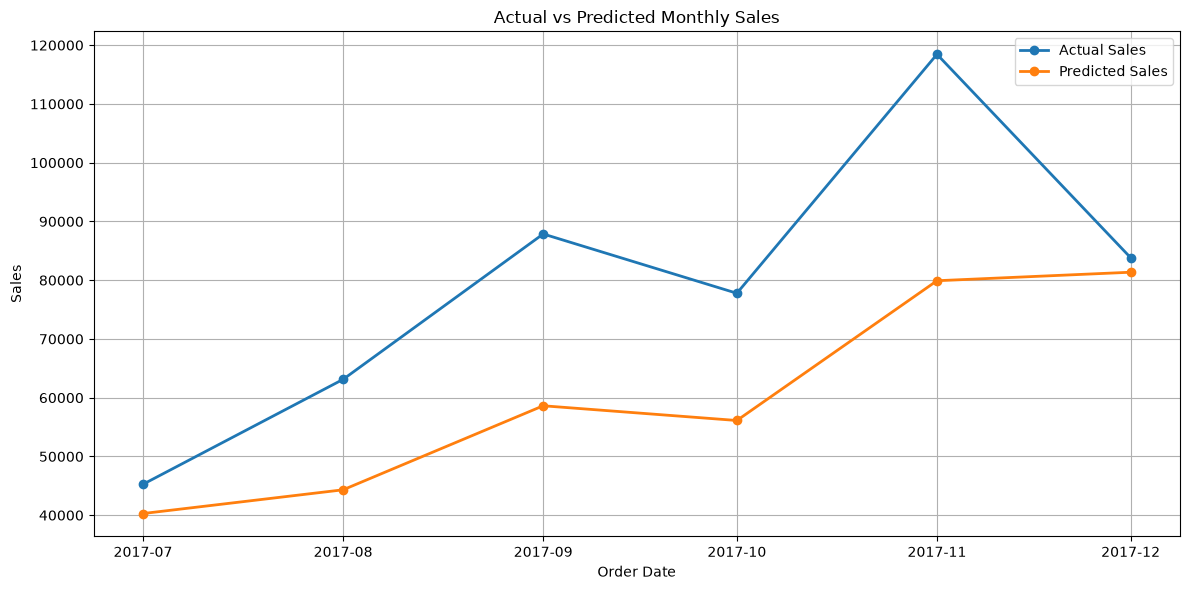

In [49]:
# Plot actual vs predicted sales

plt.figure(figsize=(12,6))

plt.plot(
    results["Date"],
    results["Actual Sales"],
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    results["Date"],
    results["Predicted Sales"],
    marker="o",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "./images/actual_vs_predicted_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
results = pd.DataFrame({
    "Date": monthly_sales["Order Date"].iloc[-6:].values,
    "Actual Sales": y_test.values,
    "Predicted Sales": predictions
})

results

,Date,Actual Sales,Predicted Sales
0,2017-07-01,45264.4160,40285.776230
1,2017-08-01,63120.8880,44325.988570
2,2017-09-01,87866.6520,58626.344963
3,2017-10-01,77776.9232,56121.354272
4,2017-11-01,118447.8250,79908.603269
5,2017-12-01,83829.3188,81355.987498


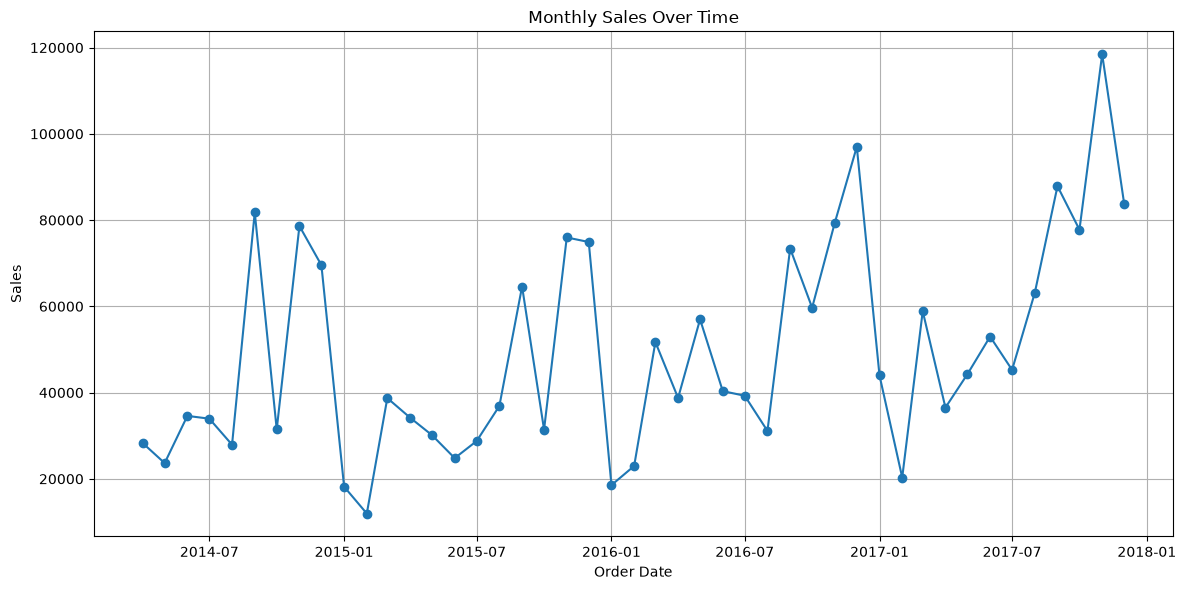

In [51]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "./images/monthly_sales_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()